# AI-Powered Fake News Detection Using Text Classification

### Objective
To build a machine learning model that classifies news articles as Real or Fake using Natural Language Processing (NLP) and Machine Learning techniques.

---

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split

# Display plots in notebook
%matplotlib inline

## Dataset Loading

The fake news dataset was obtained from Kaggle and consists of two separate files:

- **True.csv** – Contains authentic news articles.
- **Fake.csv** – Contains fabricated news articles.

Both datasets were merged into a single dataset and labeled for binary classification.

In [ ]:
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

In [ ]:
print("Fake News Dataset Shape :", fake_df.shape)
print("True News Dataset Shape :", true_df.shape)

Fake News Dataset Shape : (23481, 4)
True News Dataset Shape : (21417, 4)


In [ ]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
true_df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## Data Cleaning

The dataset was inspected for missing values, duplicate records, and inconsistencies.

Cleaning steps performed:
- Merged Fake and True datasets.
- Assigned numerical labels (1 = Real, 0 = Fake).
- Removed duplicate news articles.
- Removed unnecessary columns.
- Prepared the dataset for Natural Language Processing.

In [ ]:
fake_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [ ]:
true_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [ ]:
print("Missing values in Fake Dataset")
print(fake_df.isnull().sum())

print("\n----------------------\n")

print("Missing values in True Dataset")
print(true_df.isnull().sum())

Missing values in Fake Dataset
title      0
text       0
subject    0
date       0
dtype: int64

----------------------

Missing values in True Dataset
title      0
text       0
subject    0
date       0
dtype: int64


In [ ]:
print("Fake Dataset Duplicates :", fake_df.duplicated().sum())

print("True Dataset Duplicates :", true_df.duplicated().sum())

Fake Dataset Duplicates : 3
True Dataset Duplicates : 206


In [ ]:
fake_df["label"] = 0
true_df["label"] = 1

In [ ]:
news_df = pd.concat([fake_df, true_df], axis=0)
print("Combined Dataset Shape:", news_df.shape)

Combined Dataset Shape: (44898, 5)


In [ ]:
news_df.drop_duplicates(inplace=True)
print("Dataset Shape After Removing Duplicates:", news_df.shape)

Dataset Shape After Removing Duplicates: (44689, 5)


In [ ]:
news_df = news_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
news_df["label"].value_counts()

,count
label,
0,23478
1,21211


In [ ]:
news_df.head()

,title,text,subject,date,label
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,"A school librarian in Cambridge, Massachusetts...",left-news,"Sep 28, 2017",0
1,Kenya opposition leader calls for calm in slum...,NAIROBI (Reuters) - Kenyan opposition leader R...,worldnews,"October 29, 2017",1
2,Egypt rejects U.S. decision to move its embass...,CAIRO (Reuters) - Egypt rejected the U.S. deci...,worldnews,"December 6, 2017",1
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,After a recent speech given by Minister Louis ...,left-news,"May 8, 2015",0
4,Trump Rally Nearly Turns Into A Full-Blown Ra...,Tensions ran high outside of a campaign rally ...,News,"March 11, 2016",0


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) was performed to understand the dataset.

The following analyses were carried out:
- Class distribution of Real and Fake news.
- Word Clouds for both categories.
- Basic dataset statistics.

In [ ]:
news_df["content"] = news_df["title"] + " " + news_df["text"]

In [ ]:
news_df["label"].value_counts()

,count
label,
0,23478
1,21211


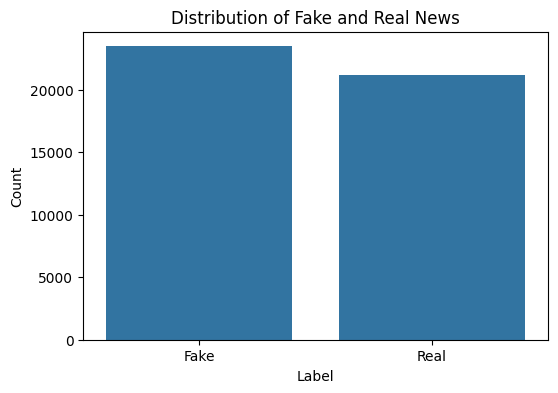

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=news_df)
plt.title("Distribution of Fake and Real News")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks([0,1],["Fake","Real"])
plt.savefig("class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
news_df["text_length"] = news_df["content"].apply(len)

In [ ]:
news_df["text_length"].describe()

,text_length
count,44689.000000
mean,2548.274005
std,2174.594406
min,31.000000
25%,1314.000000
50%,2268.000000
75%,3186.000000
max,51893.000000


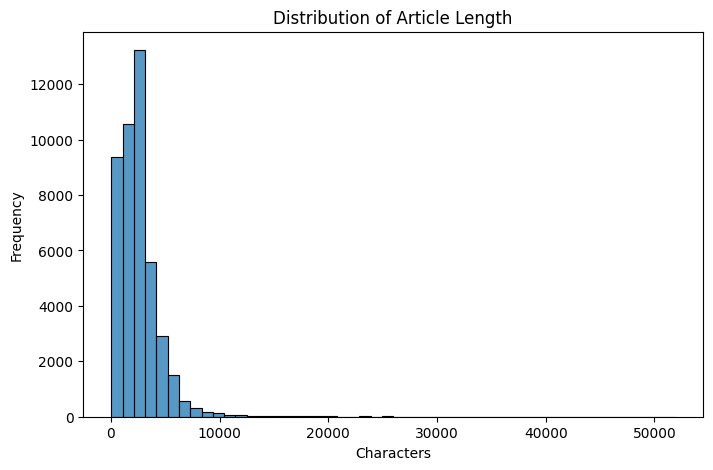

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(news_df["text_length"], bins=50)
plt.title("Distribution of Article Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.savefig("article_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

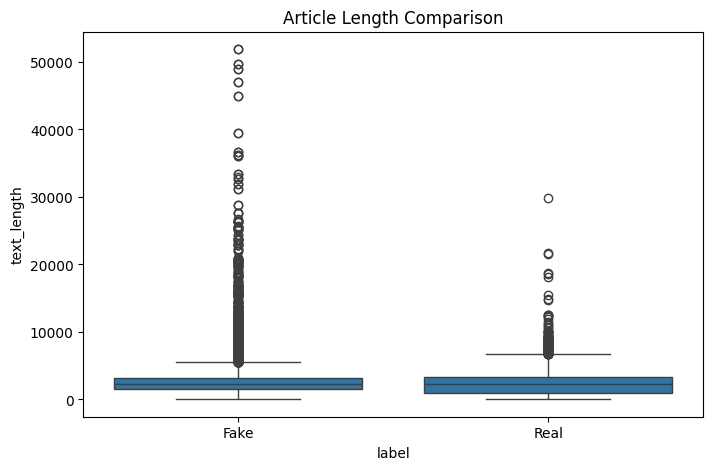

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="label", y="text_length", data=news_df)
plt.xticks([0,1],["Fake","Real"])
plt.title("Article Length Comparison")
plt.savefig("article_length_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

## Text Preprocessing

Natural Language Processing (NLP) techniques were applied to clean the news articles before training.

The preprocessing pipeline includes:
- Converting text to lowercase.
- Removing punctuation.
- Removing numbers.
- Removing extra spaces.
- Removing stopwords.
- Lemmatization.

In [ ]:
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):
    # Handle missing values
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [ ]:
news_df["clean_text"] = news_df["content"].apply(clean_text)

In [ ]:
print("Original Text:\n")
print(news_df["content"].iloc[0])
print("\n" + "="*100 + "\n")

print("Cleaned Text:\n")
print(news_df["clean_text"].iloc[0])

Original Text:

WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Children’s Books Donated By Melania Trump…Her Reason For Rejecting The Books Is DISGUSTING! A school librarian in Cambridge, Massachusetts, rejected a shipment of books that were donated by first lady Melania Trump, according to CBS Boston.#HBFamilyReading: "Dear Mrs. Trump": @reflectlibrary says, Thanks but no thanks to the First Lady + Dr. Seuss  https://t.co/98SUPkjUN6 pic.twitter.com/3t6U6vvwPI  The Horn Book (@HornBook) September 26, 2017CBS Boston on Wednesday reported that Liz Phipps Soeiro of Cambridgeport Elementary School turned down the works Trump intended to send.The White House chose one school in all 50 states to receive a package of 10 books authored by children s literary author Dr. Seuss.The initiative was meant to promote education and childhood literacy as part of National Read A Book Day.Soeiro on Tuesday penned an editorial for the Horn Book s Family Reading blog explaining why her school did not need the 

## Feature Engineering

The cleaned news articles were converted into numerical representations using the TF-IDF (Term Frequency–Inverse Document Frequency) technique.

TF-IDF assigns higher importance to informative words while reducing the influence of commonly occurring words, making it suitable for text classification tasks.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.7
)

In [ ]:
X = tfidf.fit_transform(news_df["clean_text"])

y = news_df["label"]

In [ ]:
print("Feature Matrix Shape:", X.shape)
print("Labels Shape:", y.shape)

Feature Matrix Shape: (44689, 5000)
Labels Shape: (44689,)


## Train-Test Split

The dataset was divided into training (80%) and testing (20%) sets using stratified sampling to preserve the class distribution in both subsets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (35751, 5000)
Testing Data  : (8938, 5000)


## Model Training

Four machine learning algorithms were implemented and compared:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Random Forest
- Neural Network (MLP)

Each model was trained using the same TF-IDF feature vectors to ensure a fair comparison.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

results = []

def evaluate_model(model, model_name):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print("="*60)
    print(model_name)
    print("="*60)

    print(classification_report(y_test, predictions))

    plt.figure(figsize=(5,4))

    sns.heatmap(
        confusion_matrix(y_test, predictions),
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(model_name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"{model_name}_confusion_matrix.png", dpi=300, bbox_inches="tight")

    plt.show()

## Model Evaluation

Each model was evaluated using the following performance metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

The models were compared to determine the most effective classifier for fake news detection.

Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.98      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



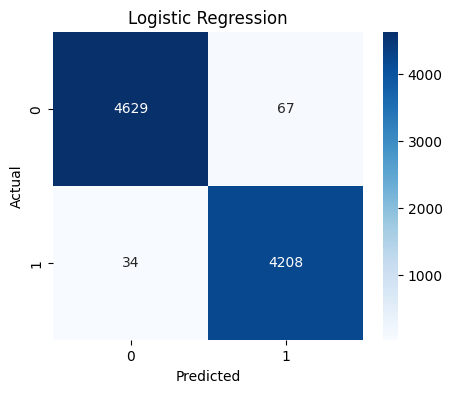

In [ ]:
lr=LogisticRegression()
evaluate_model(lr, "Logistic Regression")

KNN
              precision    recall  f1-score   support

           0       0.67      0.97      0.79      4696
           1       0.93      0.48      0.63      4242

    accuracy                           0.74      8938
   macro avg       0.80      0.72      0.71      8938
weighted avg       0.79      0.74      0.72      8938



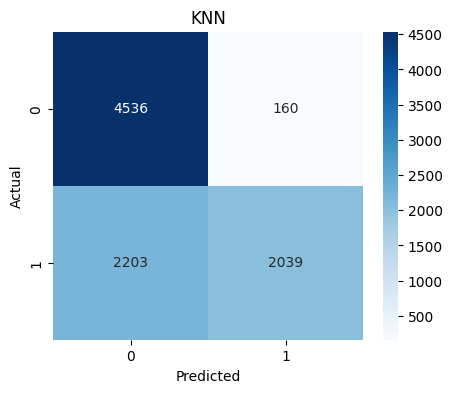

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

evaluate_model(knn, "KNN")

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



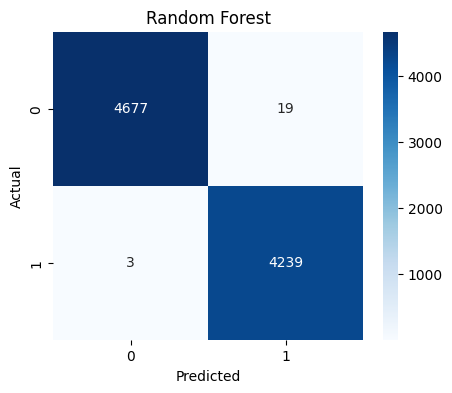

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

evaluate_model(rf, "Random Forest")

Neural Network
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.99      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



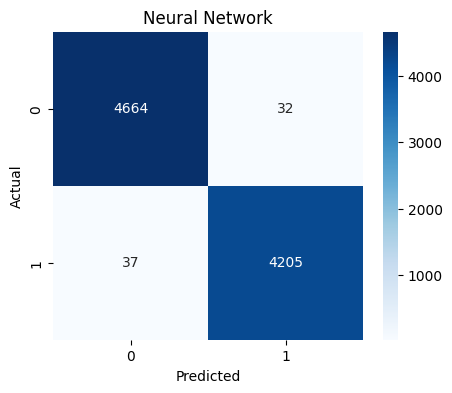

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    random_state=42
)

evaluate_model(mlp, "Neural Network")

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.997539,0.995538,0.999293,0.997412
3,Neural Network,0.992280,0.992447,0.991278,0.991862
0,Logistic Regression,0.988700,0.984327,0.991985,0.988141
1,KNN,0.735623,0.927240,0.480669,0.633132


## Saving the Best Model

The best-performing model and the TF-IDF vectorizer were saved using Joblib. This allows the trained model to be reused for future predictions without retraining.

In [ ]:
import joblib

In [ ]:
joblib.dump(rf, "fake_news_random_forest.pkl")

joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


## Prediction on Custom News

A prediction function was developed to classify unseen news articles as either **Real News** or **Fake News** using the saved machine learning model.

In [ ]:
def predict_news(news):

    cleaned = clean_text(news)

    vector = tfidf.transform([cleaned])

    prediction = rf.predict(vector)[0]

    probability = rf.predict_proba(vector)[0]

    if prediction == 0:
        print("Prediction : FAKE NEWS")
    else:
        print("Prediction : REAL NEWS")

    print()

    print(f"Confidence : {max(probability)*100:.2f}%")

In [ ]:
predict_news("""
NASA announces successful landing of astronauts on the Moon after a six-month mission.
""")

Prediction : FAKE NEWS

Confidence : 99.00%


In [ ]:
predict_news("""
Government secretly confirms aliens are controlling all world leaders through invisible satellites.
""")

Prediction : FAKE NEWS

Confidence : 75.00%


In [ ]:
sample_news = input("Enter a news article: ")

predict_news(sample_news)

Enter a news article: WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a â€œfiscal conservativeâ€ on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBSâ€™ â€œFace the Nation,â€ drew a hard line on federal spending, which lawmakers are bracing to do battle over in January. When they return from the holidays on Wednesday, lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues, such as immigration policy, even as the November congressional election campaigns approach in which Republicans will seek to keep control of Congress. President Donald Trump and his Republicans want a big budget increase in military spending, while Democrats also want proportional increases for non-defense â€œdiscretionaryâ€ spend

## Visualization & Analysis

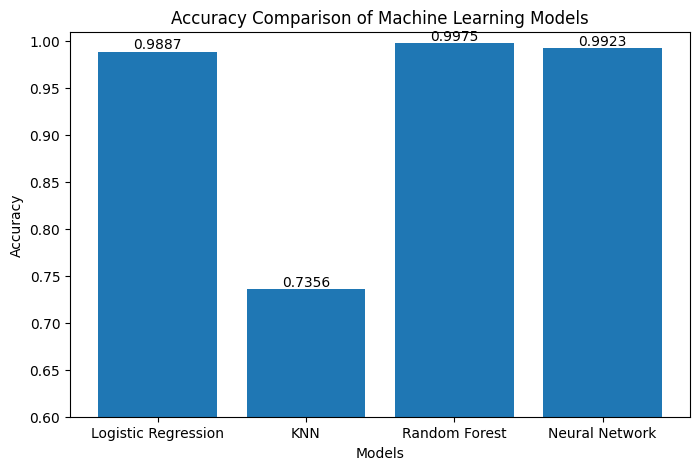

In [ ]:
plt.figure(figsize=(8,5))

bars = plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0.6, 1.01)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.4f}",
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.savefig("model_accuracy_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
from wordcloud import WordCloud

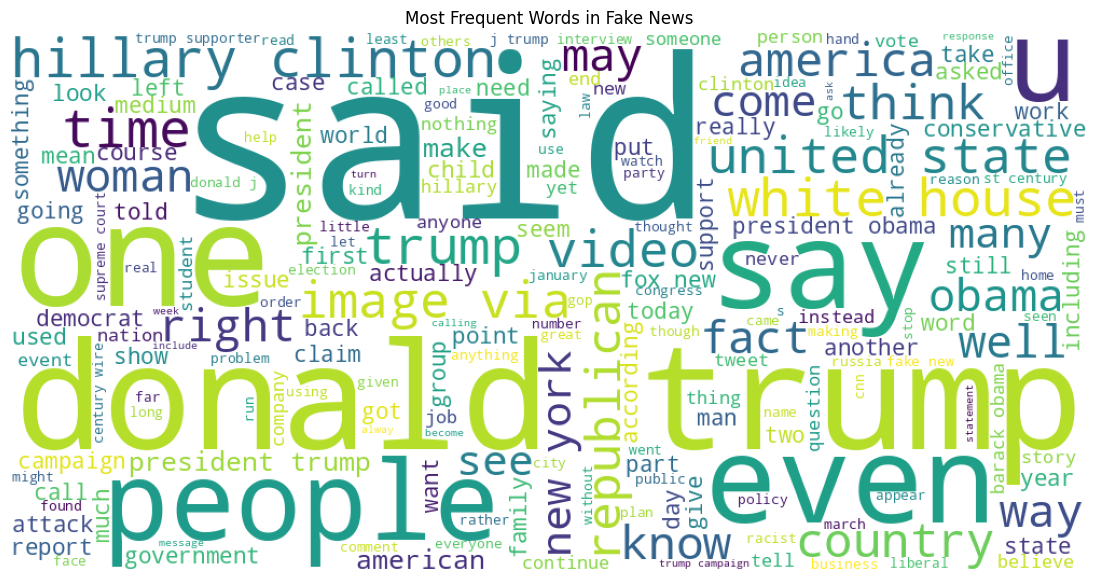

In [ ]:
fake_words = " ".join(news_df[news_df["label"] == 0]["clean_text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(fake_words)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words in Fake News")
plt.savefig("fake_news_wordcloud.png", dpi=300, bbox_inches="tight")
plt.show()

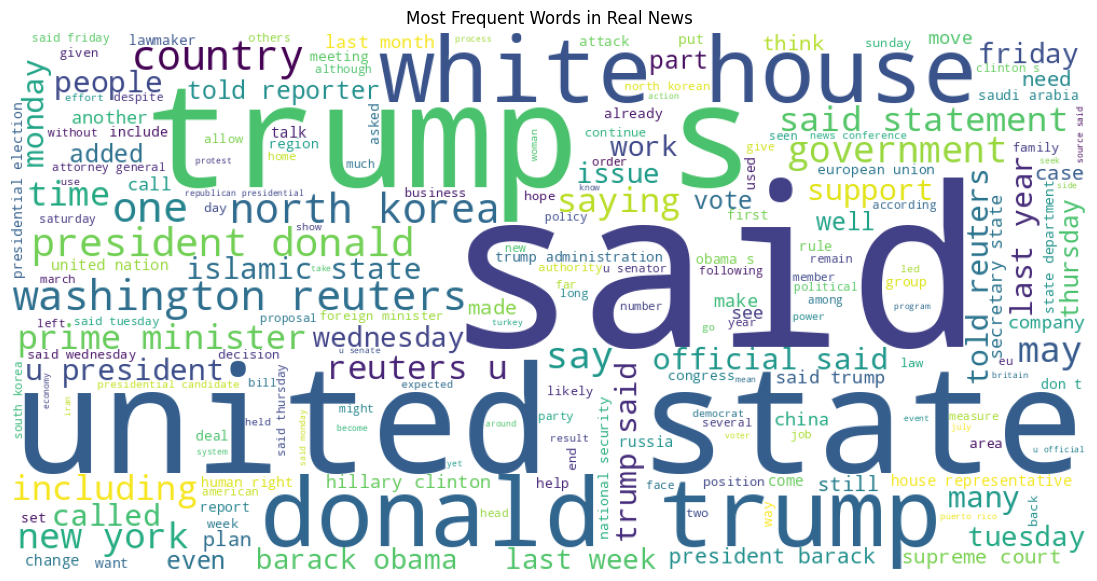

In [ ]:
real_words = " ".join(news_df[news_df["label"] == 1]["clean_text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(real_words)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words in Real News")
plt.savefig("real_news_wordcloud.png", dpi=300, bbox_inches="tight")
plt.show()

## Feature Importance

In [ ]:
feature_names = tfidf.get_feature_names_out()

importances = rf.feature_importances_

feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

top_features = feature_df.sort_values(
    by="Importance",
    ascending=False
).head(20)

top_features

,Feature,Importance
3704,reuters,0.195113
4763,video,0.042798
4753,via,0.033235
4834,washington reuters,0.029631
2100,image,0.017303
2101,image via,0.014338
2739,minister,0.012194
2500,like,0.012126
3305,president donald,0.011487
4831,washington,0.009967


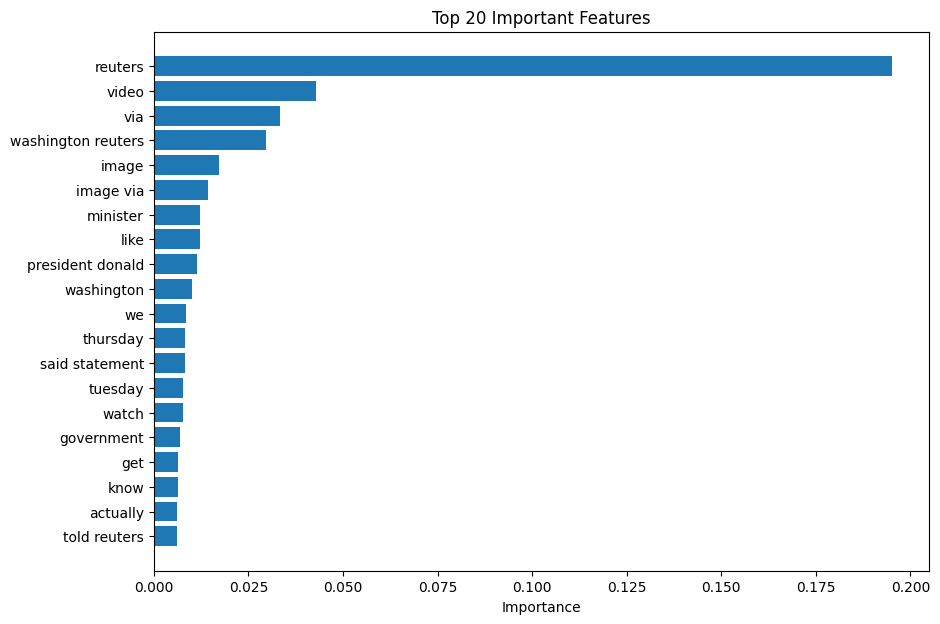

In [ ]:
plt.figure(figsize=(10,7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 20 Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## Conclusion

A complete machine learning pipeline for fake news detection was successfully developed using Natural Language Processing techniques.

The project demonstrates how machine learning can effectively identify misinformation based on textual patterns. Among the evaluated models, the best-performing classifier was selected for deployment.

Future enhancements may include using transformer-based language models such as BERT, integrating live news APIs for real-time analysis, and deploying the application using Streamlit or Flask.

## Dataset Acknowledgement

**Dataset Source:** Kaggle – Real & Fake News Dataset

**License:** CC BY-NC-SA 4.0

This dataset is used strictly for educational and non-commercial purposes in accordance with its license. Proper attribution will also be provided in the project report and presentation.